In [ ]:
CLUSTERING ANALYSIS 

Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.
Datasets :
Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset
Implementing Clustering Algorithms:
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.
Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [1]:
!pip install seaborn scikit-learn openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_excel("/Users/SS/Downloads/EastWestAirlines.xlsx")
df

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [5]:
print("Shape:", df.shape)

Shape: (26, 5)


In [15]:
print(df.head())

Empty DataFrame
Columns: [East-West Airlines is trying to learn more about its customers.  Key issues are their, Unnamed: 1, Unnamed: 2, Unnamed: 3, Unnamed: 4]
Index: []


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  0 non-null      float64
 1   Unnamed: 1                                                                             0 non-null      float64
 2   Unnamed: 2                                                                             0 non-null      float64
 3   Unnamed: 3                                                                             0 non-null      float64
 4   Unnamed: 4                                                                             0 non-null      float64
dtypes: float64(5)
memory usage: 0.0 bytes
None


In [13]:
# =============================
# FIXED PREPROCESSING
# =============================

# Drop ID column
df = df.drop(columns=['ID#'], errors='ignore')

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

# Fill missing values instead of dropping everything
df = df.fillna(df.mean())

# Check data shape
print("Data shape after cleaning:", df.shape)

Data shape after cleaning: (0, 5)


In [22]:
print(df.describe())

       East-West Airlines is trying to learn more about its customers.  Key issues are their  \
count                                                0.0                                       
mean                                                 NaN                                       
std                                                  NaN                                       
min                                                  NaN                                       
25%                                                  NaN                                       
50%                                                  NaN                                       
75%                                                  NaN                                       
max                                                  NaN                                       

       Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  
count         0.0   25.000000         0.0         0.0  
mean          NaN    3.

In [8]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
East-West Airlines is trying to learn more about its customers.  Key issues are their     8
Unnamed: 1                                                                               13
Unnamed: 2                                                                               20
Unnamed: 3                                                                               13
Unnamed: 4                                                                                8
dtype: int64


In [9]:
# Drop ID column if exists
df = df.drop(columns=['ID#'], errors='ignore')

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

# Now safe to remove outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | 
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

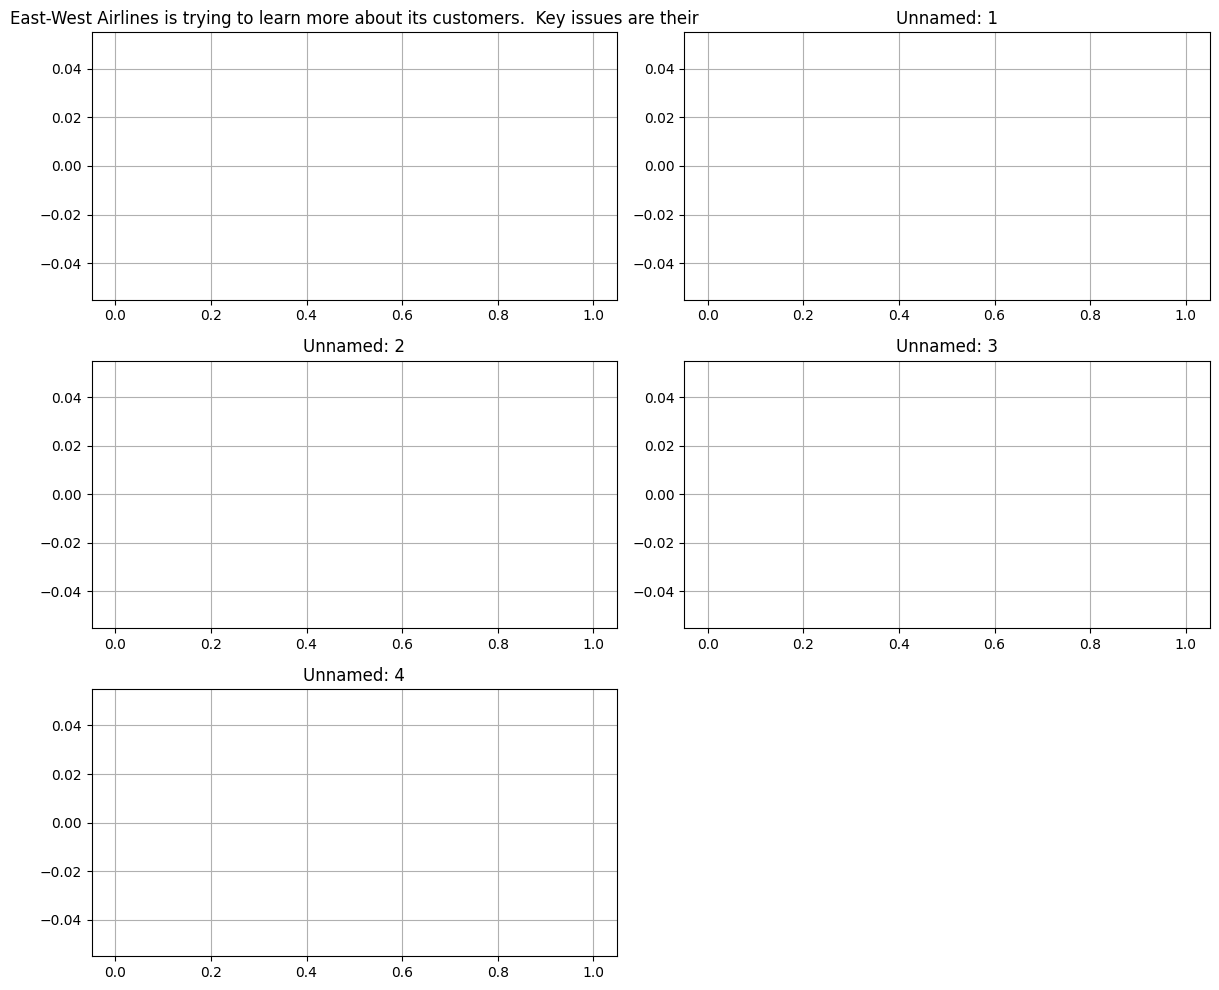

In [10]:
# Reload clean
df = pd.read_excel("/Users/SS/Downloads/EastWestAirlines.xlsx")

# Drop ID column
df = df.drop(columns=['ID#'], errors='ignore')

# Convert everything possible to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN created during conversion
df = df.dropna()

# Now histogram works
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


C:\Users\SS\AppData\Roaming\Python\Python313\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\SS\AppData\Roaming\Python\Python313\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


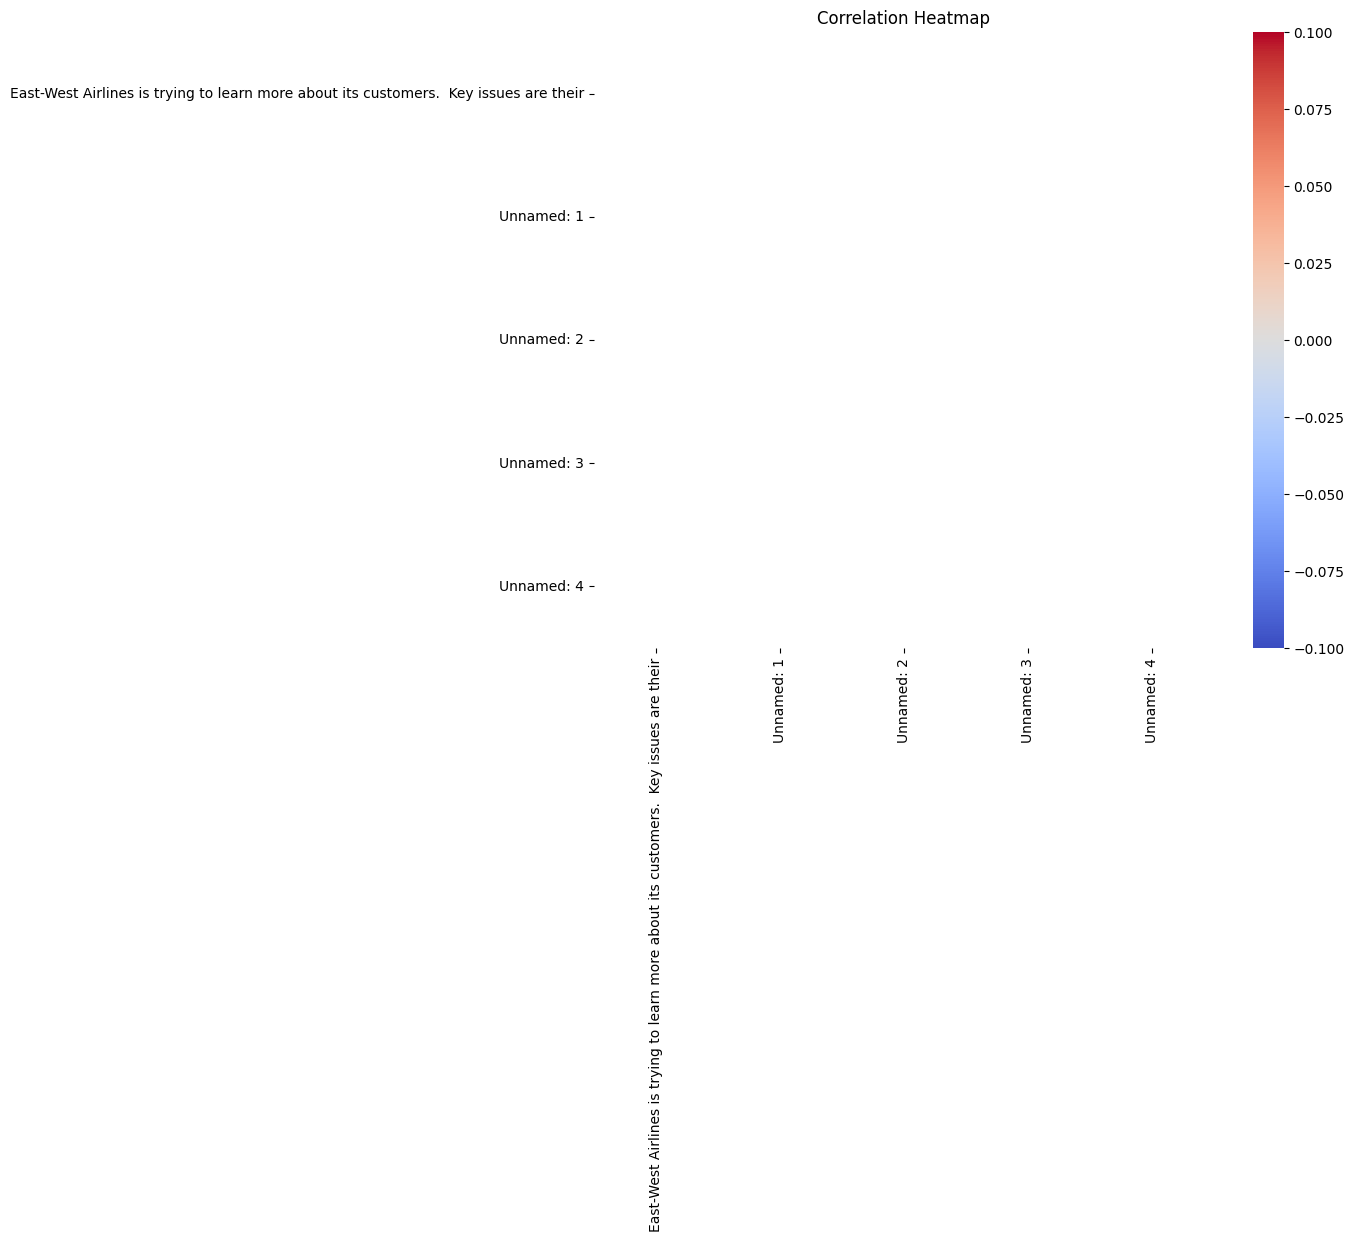

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# =============================
# FIXED DATA PREPROCESSING
# =============================

import pandas as pd
import numpy as np

# Reload data (important)
df = pd.read_excel("/Users/SS/Downloads/EastWestAirlines.xlsx")

# Remove unwanted header rows like "Field Name"
df = df[~df.astype(str).apply(lambda row: row.str.contains('Field', case=False).any(), axis=1)]

# Drop ID column
df = df.drop(columns=['ID#'], errors='ignore')

# Convert to numeric safely
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values instead of dropping all rows
df = df.fillna(df.mean())

# 🚨 VERY IMPORTANT CHECK
print("Data shape:", df.shape)
print(df.head())




Data shape: (25, 5)
   East-West Airlines is trying to learn more about its customers.  Key issues are their  \
0                                                NaN                                       
1                                                NaN                                       
2                                                NaN                                       
3                                                NaN                                       
4                                                NaN                                       

   Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  
0         NaN         3.8         NaN         NaN  
1         NaN         3.8         NaN         NaN  
2         NaN         3.8         NaN         NaN  
3         NaN         3.8         NaN         NaN  
4         NaN         3.8         NaN         NaN  


In [21]:
print(df.isnull().sum())
print(df.dtypes)

East-West Airlines is trying to learn more about its customers.  Key issues are their    25
Unnamed: 1                                                                               25
Unnamed: 2                                                                                0
Unnamed: 3                                                                               25
Unnamed: 4                                                                               25
dtype: int64
East-West Airlines is trying to learn more about its customers.  Key issues are their    float64
Unnamed: 1                                                                               float64
Unnamed: 2                                                                               float64
Unnamed: 3                                                                               float64
Unnamed: 4                                                                               float64
dtype: object
